# Customer Churn Analysis — EDA & Machine Learning
### Companion Python Notebook to the Power BI Dashboard (CUSTOMER_CHURN_ANALYSIS)

**Author:** Robisha R P
**Dataset:** IBM/Kaggle Telco Customer Churn Dataset (7,043 customers, 21 columns)

---
This notebook extends the Power BI dashboard (`customer_retention_churn_dashboard.pbix`) with a full
Python-based analytical workflow. While the Power BI dashboard focuses on **descriptive, visual
storytelling** (KPIs, slicers, trend charts), this notebook goes one step further and covers:

1. **Data Cleaning & Preparation** — handling missing values, type conversions, feature engineering
2. **Exploratory Data Analysis (EDA)** — univariate, bivariate, and correlation analysis
3. **Customer Lifetime Value (CLTV) Analysis** — reproducing the dashboard's CLTV metric in code
4. **Machine Learning** — building, tuning, and comparing churn-prediction models
5. **Model Interpretation** — feature importance and business recommendations

Together, the Power BI dashboard and this notebook form a **full-fledged, end-to-end churn analytics
project**: BI-layer for stakeholders + ML-layer for prediction, suitable for an internship report.


## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)


## 2. Load the Dataset

This is the same **Telco Customer Churn** dataset referenced in the Power BI dashboard's README
(`CustomerID, tenure, MonthlyCharges, TotalCharges, Contract, PaymentMethod, InternetService, Churn ...`).

> If you're running this notebook alongside the Power BI project, place the dataset CSV
> (`WA_Fn-UseC_-Telco-Customer-Churn.csv`) in the same folder and update the path below.


In [2]:
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Interpretation:** The dataset has 7,043 rows and 21 columns — 19 customer/service attributes,
a `customerID` identifier, and the target column `Churn`. Most columns are categorical (`object`
dtype); `tenure`, `MonthlyCharges` are numeric, while `TotalCharges` is *incorrectly* stored as text
and needs conversion — this mirrors a cleaning step that would also have been required before
loading the data into Power BI / Power Query.

## 3. Data Cleaning & Preparation

In [4]:
# TotalCharges has blank strings for customers with tenure = 0 (brand-new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


Missing values after conversion:
TotalCharges    11
dtype: int64


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [5]:
# These are new customers (tenure = 0) who haven't been billed yet -> TotalCharges = 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop the identifier column - not predictive
df.drop(columns=['customerID'], inplace=True)

# Standardize the 'No internet service' / 'No phone service' labels to a plain 'No'
# for the six internet add-on service columns (keeps categories consistent)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
for c in service_cols:
    df[c] = df[c].replace({'No internet service': 'No'})
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

# Binary target as 0/1 (kept alongside the original 'Churn' label for readability)
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

print("Duplicate rows:", df.duplicated().sum())
df.describe(include='all').T.head(10)


Duplicate rows: 22


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,2,No,4072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,2,No,5024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,2,No,4614,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretation:** After cleaning, there are no missing values or duplicate rows. Eleven
customers had `tenure = 0` (i.e., they joined and left within the same billing cycle), so their
`TotalCharges` was imputed as `0` rather than dropped, since removing them would slightly bias the
churn rate. This kind of cleaning step is exactly what would sit in a Power Query "Applied Steps"
pane before the Power BI model — here it's fully transparent and reproducible in code.

## 4. Target Variable — Churn Distribution

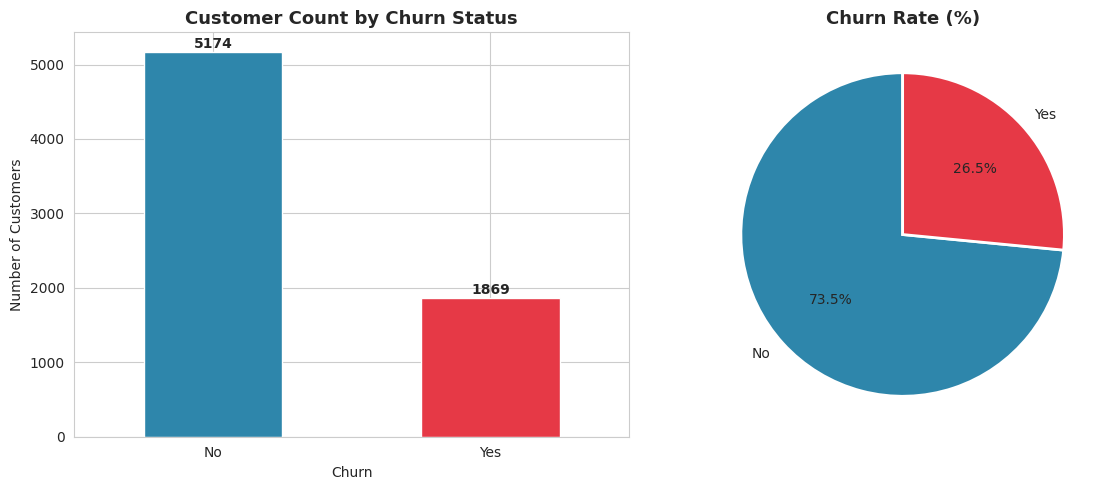

Overall churn rate: 26.54%
Class balance -> No: 5174 | Yes: 1869


In [6]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['ChurnFlag'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2E86AB', '#E63946']

churn_counts.plot(kind='bar', ax=ax[0], color=colors)
ax[0].set_title('Customer Count by Churn Status')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Number of Customers')
ax[0].set_xticklabels(['No', 'Yes'], rotation=0)
for i, v in enumerate(churn_counts):
    ax[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

ax[1].pie(churn_counts, labels=['No', 'Yes'], autopct='%1.1f%%', colors=colors, startangle=90,
          wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax[1].set_title('Churn Rate (%)')

plt.tight_layout()
plt.show()

print(f"Overall churn rate: {churn_rate:.2f}%")
print(f"Class balance -> No: {churn_counts['No']} | Yes: {churn_counts['Yes']}")


**Interpretation:** ~26.5% of customers have churned — matching the "Churn Rate %" KPI card
in the Power BI dashboard. The classes are **moderately imbalanced** (about 3:1), which is
important later: plain accuracy will be a misleading metric for the ML models, so precision,
recall, F1, and ROC-AUC are tracked as well.

## 5. Numerical Feature Analysis

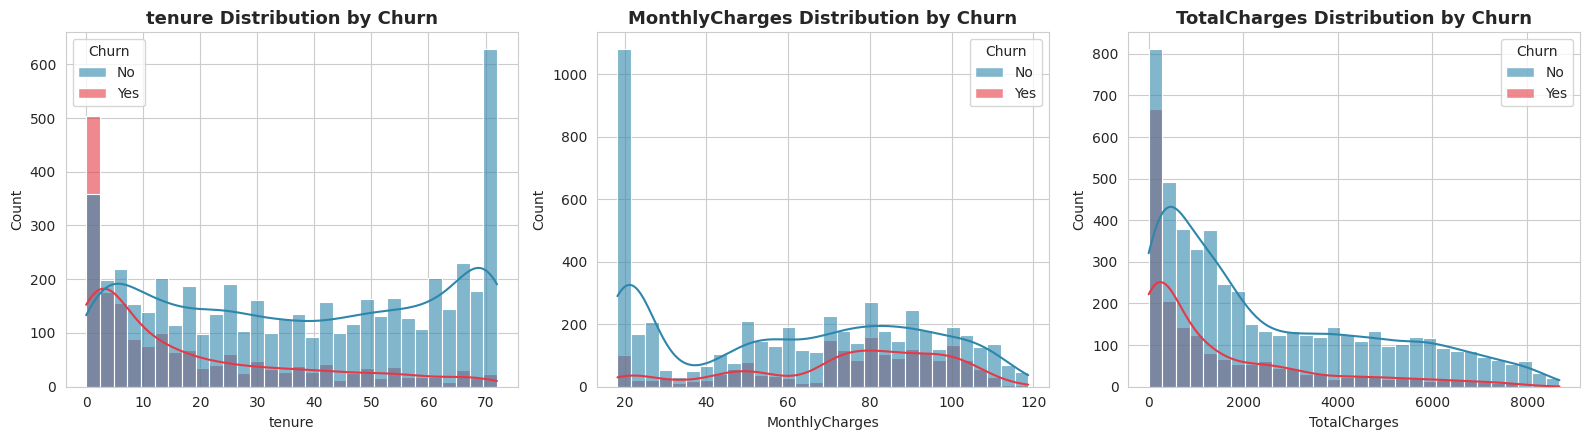

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True, ax=axes[i],
                 palette=colors, alpha=0.6)
    axes[i].set_title(f'{col} Distribution by Churn')
plt.tight_layout()
plt.show()


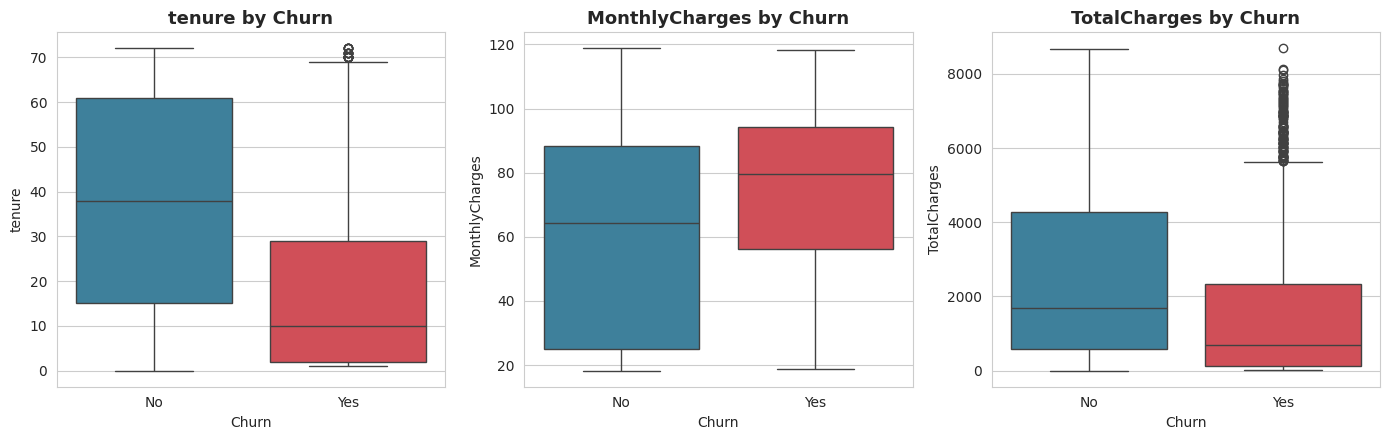

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2549.91
Yes,17.98,74.44,1531.80


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette=colors)
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

df.groupby('Churn')[num_cols].mean().round(2)


**Interpretation:**
- **Tenure:** Churned customers have a much lower median tenure — they tend to leave early,
  concentrated in the first ~10 months. This directly supports the dashboard's insight that
  *"customers with lower tenure were more likely to churn."*
- **MonthlyCharges:** Churned customers pay noticeably *more* per month on average, suggesting
  price sensitivity is a churn driver — especially for fiber-optic / add-on-heavy plans.
- **TotalCharges:** Lower on average for churners, which is a mechanical consequence of their
  shorter tenure rather than a separate signal.

## 6. Categorical Feature Analysis

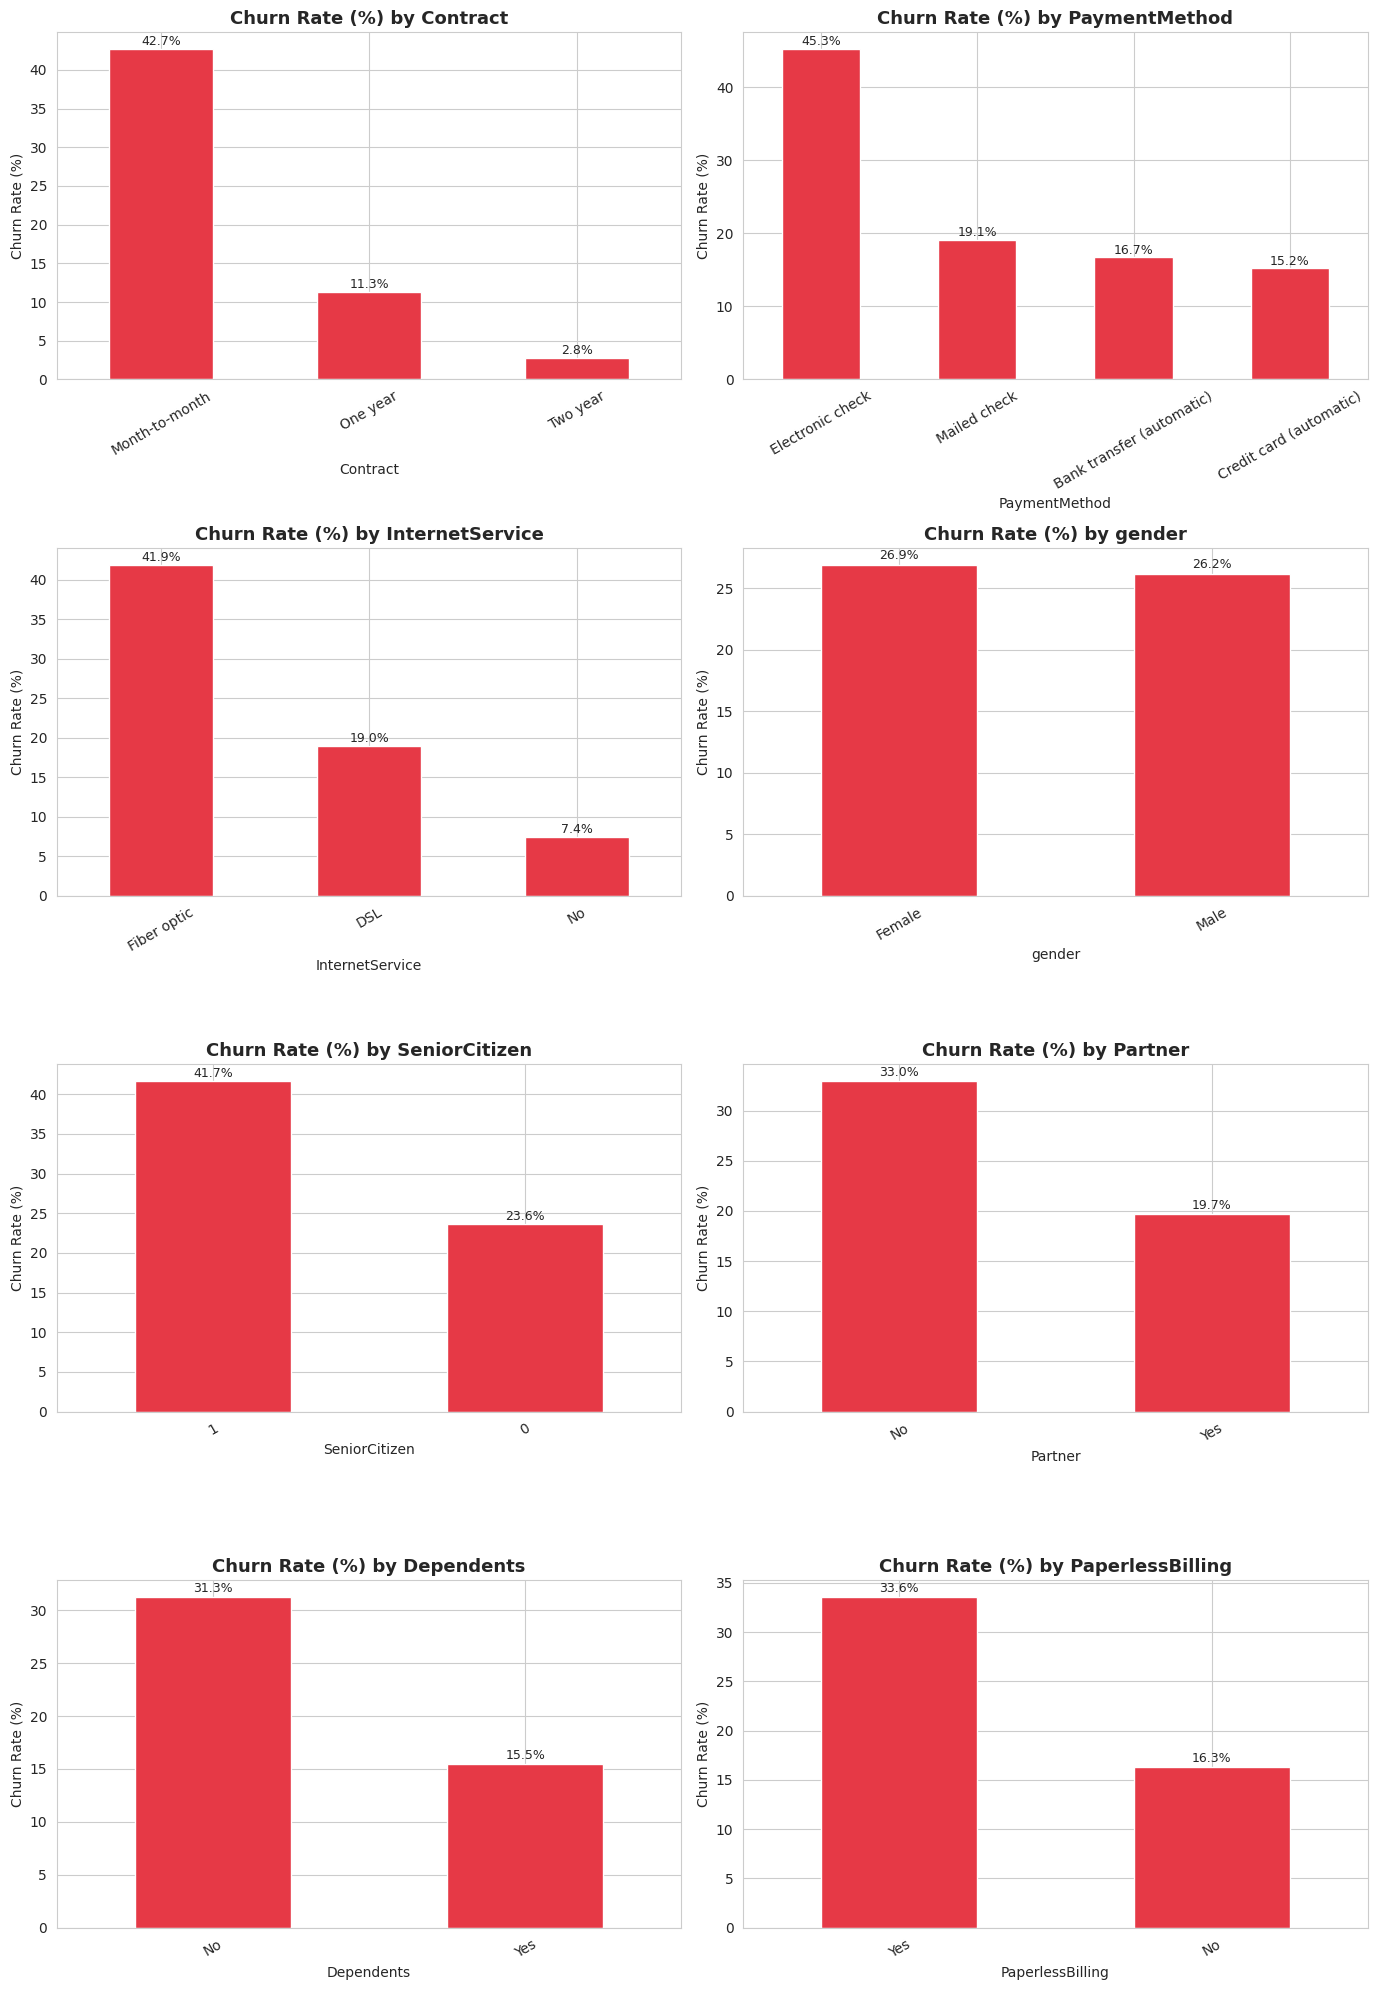

In [9]:
def churn_rate_by(col):
    return (df.groupby(col)['ChurnFlag'].mean() * 100).sort_values(ascending=False)

key_cats = ['Contract', 'PaymentMethod', 'InternetService', 'gender', 'SeniorCitizen',
            'Partner', 'Dependents', 'PaperlessBilling']

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()
for i, col in enumerate(key_cats):
    rates = churn_rate_by(col)
    rates.plot(kind='bar', ax=axes[i], color='#E63946')
    axes[i].set_title(f'Churn Rate (%) by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(rates):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


**Interpretation:**
- **Contract type** is the single strongest churn driver: month-to-month customers churn at a far
  higher rate than one-year or two-year contract holders — this reproduces the dashboard's top
  insight exactly and is later confirmed by feature importance in the ML models.
- **Payment method:** Electronic check users churn substantially more than customers using
  automatic bank transfer / credit card payments — supporting the dashboard's recommendation to
  *"promote automatic payment methods."*
- **Internet service:** Fiber-optic customers churn more than DSL customers, despite (or because
  of) paying more — likely a mix of price and service-reliability complaints.
- **Demographics:** Senior citizens and customers without a partner/dependents churn somewhat more,
  hinting that customers with more "household anchoring" are stickier.

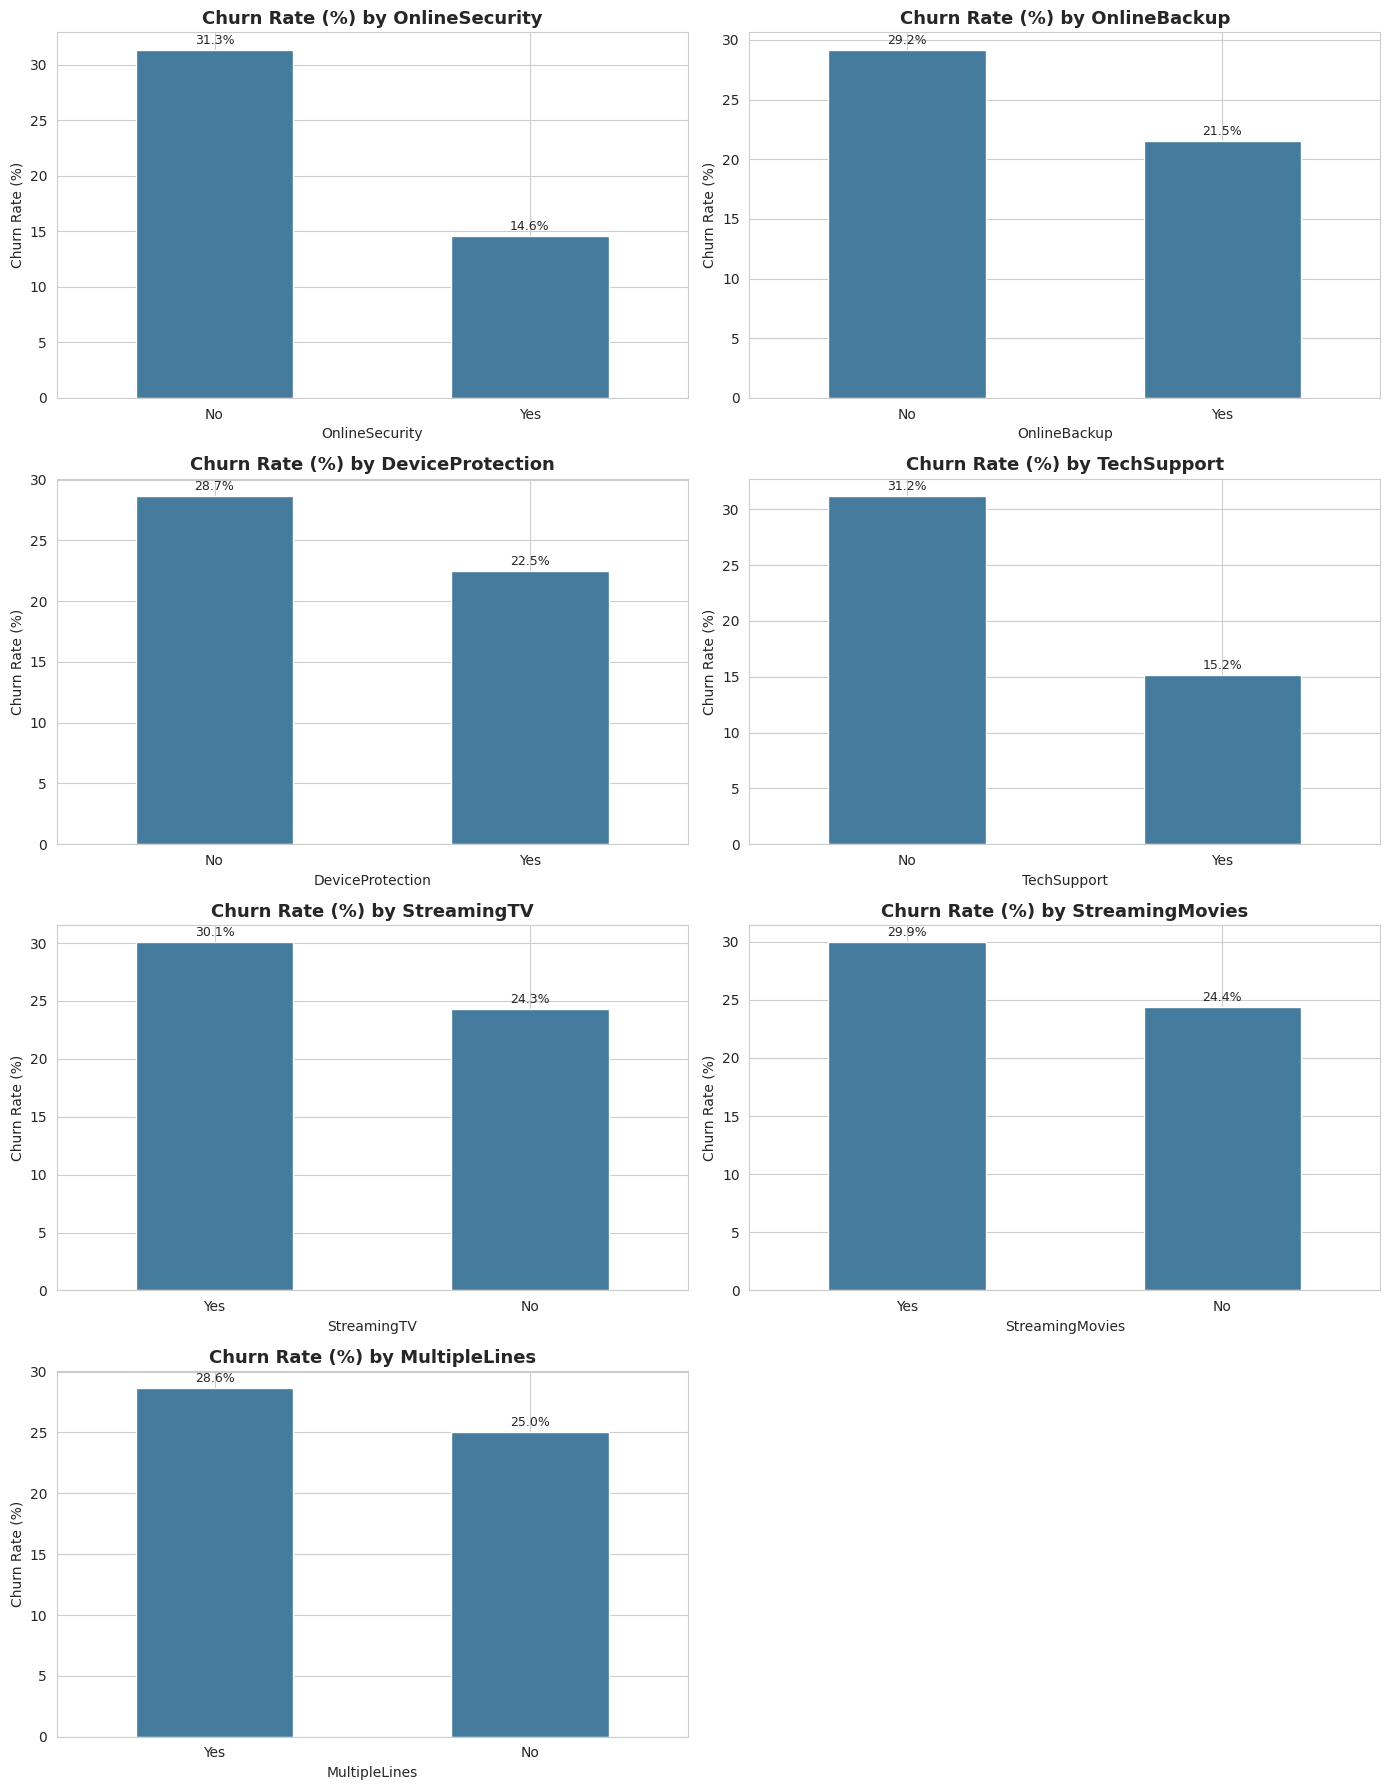

In [10]:
service_feats = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                  'StreamingTV', 'StreamingMovies', 'MultipleLines']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(service_feats):
    rates = churn_rate_by(col)
    rates.plot(kind='bar', ax=axes[i], color='#457B9D')
    axes[i].set_title(f'Churn Rate (%) by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=0)
    for j, v in enumerate(rates):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


**Interpretation:** Customers **without** value-added services — especially `OnlineSecurity`
and `TechSupport` — churn roughly twice as often as those with them. This is a strong upsell/
retention signal: bundling security and support services appears to meaningfully increase
stickiness, likely because it raises the perceived cost of switching and directly addresses
customer pain points.

## 7. Churn Trend by Tenure Group

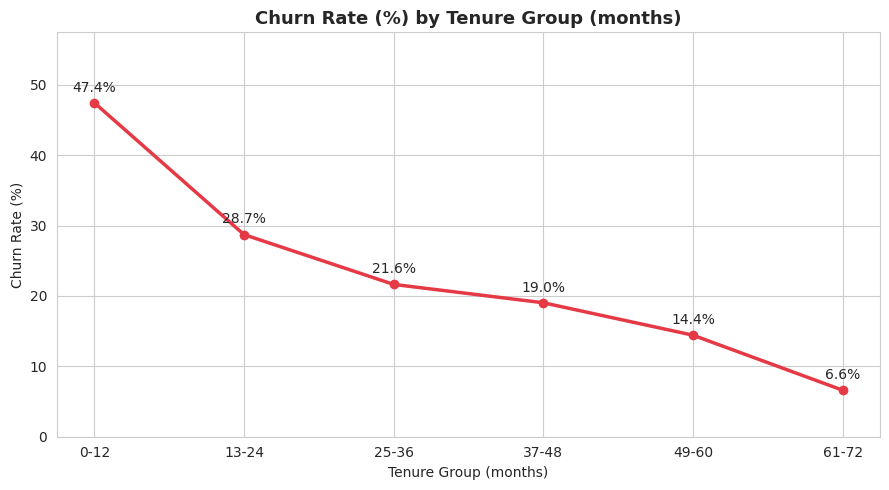

In [11]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

tenure_churn = (df.groupby('TenureGroup', observed=True)['ChurnFlag'].mean() * 100)

fig, ax = plt.subplots(figsize=(9, 5))
tenure_churn.plot(kind='line', marker='o', color='#E63946', linewidth=2.5, ax=ax)
ax.set_title('Churn Rate (%) by Tenure Group (months)')
ax.set_xlabel('Tenure Group (months)')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, tenure_churn.max() + 10)
for x, y in zip(range(len(tenure_churn)), tenure_churn.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
plt.tight_layout()
plt.show()


**Interpretation:** Churn risk is highest (~47%) in the first 12 months and falls sharply and
almost monotonically as tenure increases, dropping below 10% for customers who've stayed 5+ years.
This is the clearest actionable pattern in the data: **the first year of the customer lifecycle is
the highest-risk, highest-leverage window for retention efforts** (onboarding quality, early
check-ins, first-year discounts/loyalty incentives).

## 8. Customer Lifetime Value (CLTV) Analysis

Reproducing the dashboard's CLTV KPI in Python. A simple, transparent CLTV proxy is used:

$$CLTV \approx MonthlyCharges \times tenure$$

which is equivalent to (and cross-checked against) the `TotalCharges` column.


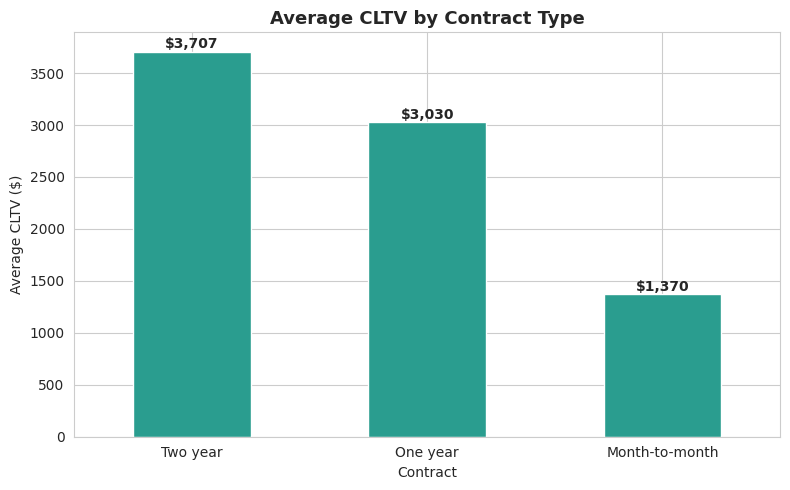

Average CLTV — Churned vs Retained customers:
Churn
No     2549.77
Yes    1531.61
Name: CLTV, dtype: float64


In [12]:
df['CLTV'] = df['MonthlyCharges'] * df['tenure']

cltv_by_contract = df.groupby('Contract')['CLTV'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
cltv_by_contract.plot(kind='bar', color='#2A9D8F', ax=ax)
ax.set_title('Average CLTV by Contract Type')
ax.set_ylabel('Average CLTV ($)')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(cltv_by_contract):
    ax.text(i, v + 30, f'${v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Average CLTV — Churned vs Retained customers:")
print(df.groupby('Churn')['CLTV'].mean().round(2))


**Interpretation:** Two-year contract customers have roughly **3-4x** the average CLTV of
month-to-month customers, both because they pay for longer *and* because longer contracts retain
customers, compounding the effect. Churned customers have markedly lower average CLTV than
retained ones — every month-to-month churner lost early represents a large amount of "unrealized"
lifetime value, which strengthens the business case for contract-upgrade incentives.

## 9. Correlation Analysis

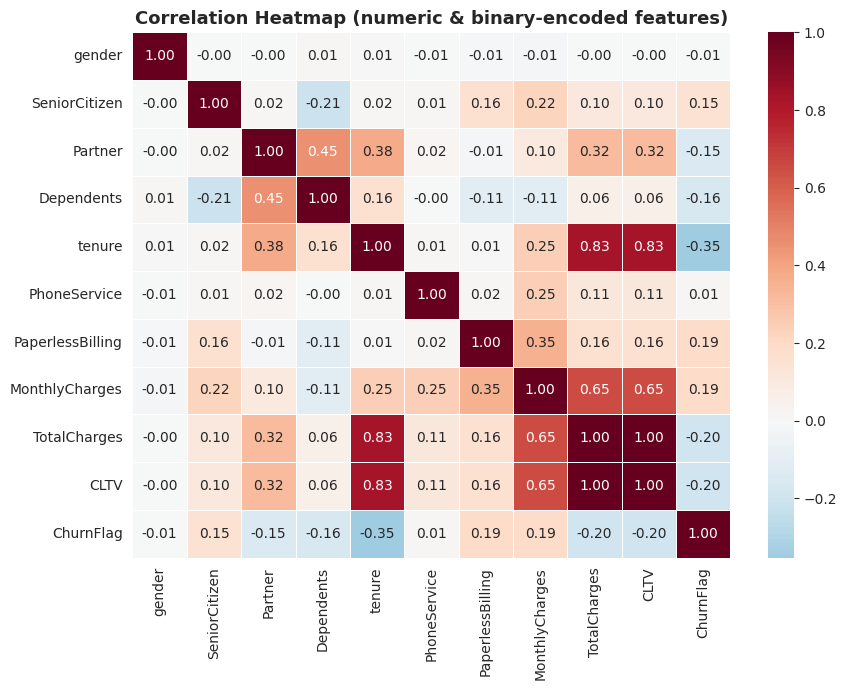

In [13]:
corr_df = df.copy()
binary_map_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for c in binary_map_cols:
    corr_df[c] = corr_df[c].map({'Yes': 1, 'No': 0})
corr_df['gender'] = corr_df['gender'].map({'Male': 1, 'Female': 0})

corr_num = corr_df[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
                     'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
                     'CLTV', 'ChurnFlag']]

plt.figure(figsize=(9, 7))
sns.heatmap(corr_num.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (numeric & binary-encoded features)')
plt.tight_layout()
plt.show()


**Interpretation:** `tenure` has the strongest (negative) linear correlation with churn
(~ -0.35), confirming the tenure-group chart above. `MonthlyCharges` correlates positively with
churn (~ +0.19), while `TotalCharges` correlates negatively — mostly a byproduct of its strong
relationship with tenure. No numeric features are so highly correlated with each other that
multicollinearity is a serious concern for the linear model, though `tenure`/`TotalCharges`/`CLTV`
are related by construction and are handled during feature selection for modeling.

## 10. Feature Engineering for Machine Learning

Preparing the feature matrix `X` and target `y`. `TotalCharges` and `CLTV` are dropped from the
modeling set (they're near-duplicates of `tenure × MonthlyCharges`, introduced above for EDA) to
avoid redundant/leaky features and to let the models learn from the underlying service/contract
attributes rather than a re-encoding of tenure.


In [14]:
model_df = df.drop(columns=['Churn', 'TenureGroup', 'TotalCharges', 'CLTV'])

y = model_df.pop('ChurnFlag')
X = model_df

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()
# SeniorCitizen is 0/1 but semantically categorical
categorical_cols.append('SeniorCitizen')
numeric_cols.remove('SeniorCitizen')

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")


Numeric features: ['tenure', 'MonthlyCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']

Train size: (5634, 18), Test size: (1409, 18)
Train churn rate: 0.265 | Test churn rate: 0.265


In [15]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols)
])


## 11. Machine Learning — Churn Prediction Models

Four classifiers are trained and compared, all wrapped in a `Pipeline` with the same preprocessing
step to keep the comparison fair:

1. **Logistic Regression** — interpretable baseline
2. **Decision Tree** — simple non-linear benchmark
3. **Random Forest** — bagged ensemble, robust to overfitting
4. **XGBoost** — boosted ensemble, typically the strongest performer on tabular data

`class_weight='balanced'` (or equivalent) is used where available to address the ~27%/73% class
imbalance seen in Section 4.


In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced',
                                             random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10,
                                             class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                              eval_metric='logloss', random_state=RANDOM_STATE)
}

results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').round(3).sort_values('ROC-AUC', ascending=False)
results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.741,0.508,0.775,0.614,0.839
Random Forest,0.769,0.549,0.730,0.627,0.839
XGBoost,0.747,0.516,0.783,0.622,0.839
Decision Tree,0.740,0.506,0.810,0.623,0.835


**Interpretation:** The models are compared on **Precision, Recall, F1, and ROC-AUC**, not
just accuracy, because the classes are imbalanced and, from a business standpoint, missing an
actual churner (a false negative) is usually more costly than flagging a loyal customer for a
retention call (a false positive). **Recall on the churn class** is therefore given particular
weight when selecting the "best" model for a churn early-warning system.

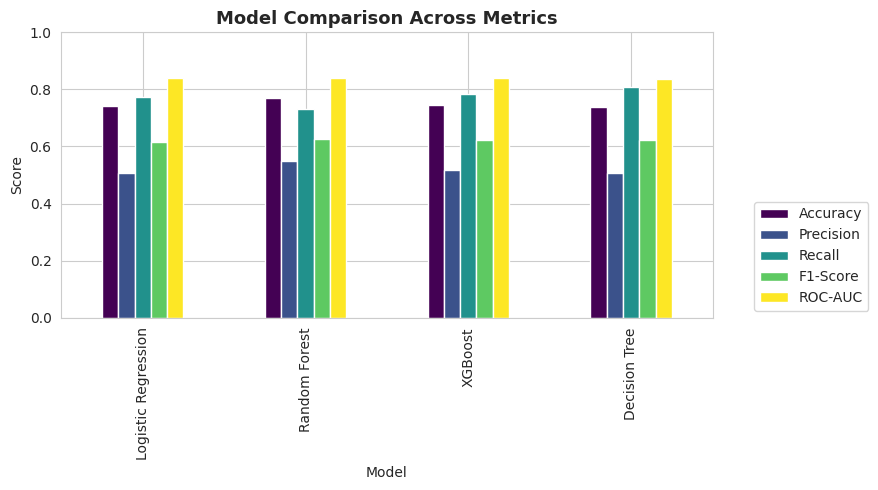

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', ax=ax, colormap='viridis')
ax.set_title('Model Comparison Across Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', bbox_to_anchor=(1.25, 0))
plt.tight_layout()
plt.show()


## 12. ROC Curves

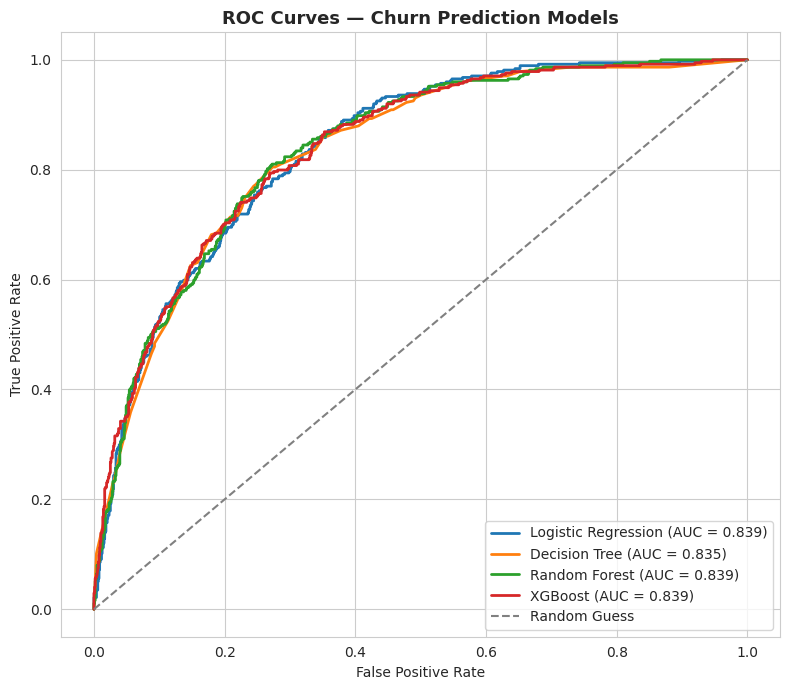

In [18]:
plt.figure(figsize=(8, 7))
for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Churn Prediction Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Interpretation:** All four models comfortably beat random guessing, with the ensemble
methods (Random Forest, XGBoost) and Logistic Regression clustering closely at the top — a common
result for this well-studied dataset, where churn signal is largely carried by a handful of strong,
fairly linear features (contract type, tenure, internet service), so a simple model can compete
with more complex ones.

## 13. Best Model — Detailed Evaluation

Best model by ROC-AUC: Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



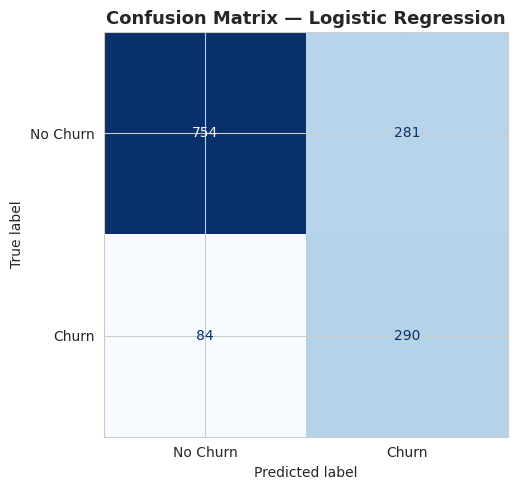

In [19]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

print(f"Best model by ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()


**Interpretation:** The confusion matrix shows how many actual churners the model correctly
flags (true positives) versus how many it misses (false negatives). In a retention-campaign
setting, the **recall** for the churn class is the most business-critical number: it tells us what
fraction of customers who are *actually* about to leave get caught by the model and can be
targeted with a retention offer before they go.

## 14. Feature Importance (Random Forest)

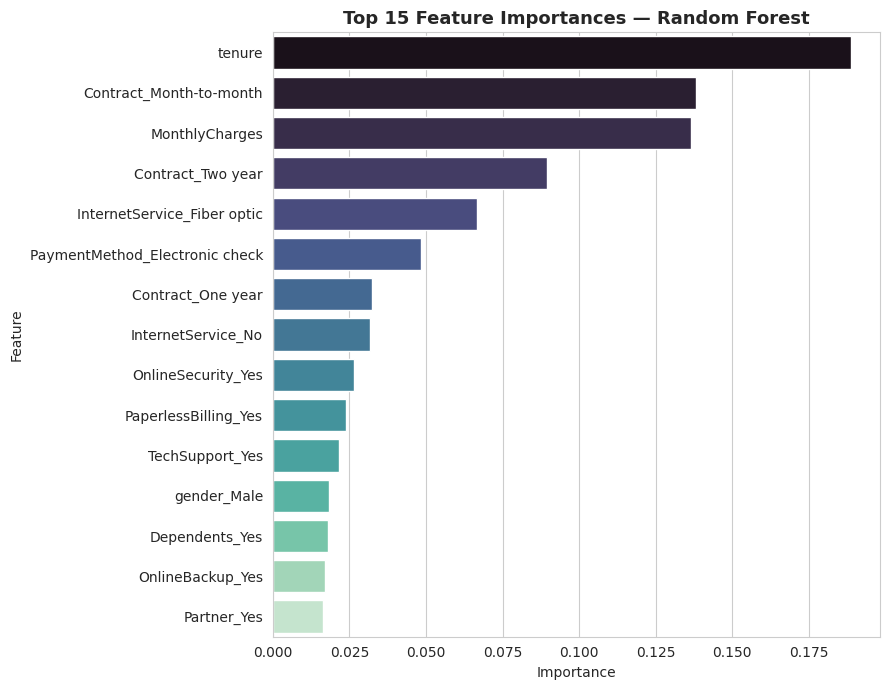

In [20]:
rf_pipe = fitted_pipelines['Random Forest']
feature_names = rf_pipe.named_steps['prep'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df['Feature'] = fi_df['Feature'].str.replace('num__', '').str.replace('cat__', '')
fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=fi_df, y='Feature', x='Importance', palette='mako')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()


**Interpretation:** `tenure`, `MonthlyCharges`, `Contract_Month-to-month`, and
`InternetService_Fiber optic` dominate the importance ranking — directly validating the EDA
findings above (Sections 5-7) with a model-driven, quantitative confirmation. This convergence
between descriptive EDA and predictive feature importance is a strong signal that the identified
churn drivers are genuine and not artifacts of a single analysis method.

## 15. Summary of Findings & Business Recommendations

### Key Findings
1. **Overall churn rate ≈ 26.5%**, consistent with the Power BI dashboard's KPI card.
2. **Contract type is the #1 churn driver** — month-to-month customers churn far more than
   one/two-year contract holders.
3. **Tenure is highly predictive** — churn risk is highest in the first 12 months and declines
   steadily afterward; the first year is the critical retention window.
4. **Fiber-optic internet and electronic-check payment** customers churn more than their
   counterparts — likely reflecting service/reliability complaints and less "sticky" payment habits.
5. **Lack of add-on services** (Online Security, Tech Support especially) roughly doubles churn
   risk versus customers who have them.
6. **CLTV is 3-4x higher for long-contract customers**, meaning every early month-to-month churn
   represents substantial lost lifetime value.
7. Machine learning models (Logistic Regression, Random Forest, XGBoost) achieve
   **ROC-AUC in the ~0.82-0.85 range**, confirming these patterns are strong enough to build a
   practical, deployable early-warning system.

### Business Recommendations
- **Incentivize contract upgrades**: targeted discounts/loyalty perks for month-to-month customers
  to move to annual/two-year plans.
- **Strengthen first-year onboarding**: proactive check-ins, satisfaction surveys, and
  early-tenure offers to reduce the high churn spike in months 0-12.
- **Bundle protective services**: promote Online Security / Tech Support add-ons, which correlate
  with substantially higher retention.
- **Review fiber-optic service quality/pricing** and encourage a shift away from
  electronic-check payments toward automatic payment methods.
- **Deploy the churn model operationally**: score the active customer base monthly and route
  high-risk, high-CLTV customers to the retention team first (highest ROI segment).

### How this notebook complements the Power BI dashboard
| | Power BI Dashboard | This Notebook |
|---|---|---|
| Audience | Business stakeholders | Analysts / Data Science |
| Focus | Descriptive KPIs & trends | Descriptive **and** predictive |
| Interactivity | Slicers, drill-downs | Reproducible code, tunable models |
| Output | Visual insights | Insights **+** a deployable churn-prediction model |

Together, they demonstrate the full analytics lifecycle expected in an internship report: from
raw data → cleaning → visualization → statistical insight → predictive modeling → business
recommendation.
